# Coherent Hamming-weight circuits: verification + two application directions
**v2 of `Untitled5.ipynb`** — generated and executed by Claude. All outputs below are saved in the file, so you can read the results without re-running.

### What changed vs `Untitled5.ipynb`
| # | Change | Why |
|---|--------|-----|
| 1 | Replaced the 4 duplicate Algorithm-1 cells with one clean **unitary** weight circuit (`weight_unitary`) | The measurement-free form `\|x>\|0> -> \|x>\|W(x)>` is what other algorithms need to call |
| 2 | `QFT` → `QFTGate(k).inverse()` | `QFT` is deprecated since Qiskit 2.1 |
| 3 | Tested on **superposition** inputs against the paper's benchmark $\|\|P_x\psi\|\|^2$ | v1 only tested the basis state `"11"` |
| 4 | **New:** DNA mismatch counting using the weight circuit (Paper 3 domain) | Link between Papers 2 and 3 |
| 5 | **New:** `hwb` (Paper 1) built from the weight register, with resource scaling | Link between Papers 2 and 1 |
| 6 | *Not yet done:* depth-optimal circuit (still broken in v1), noise models, ZNE | Planned next |


In [1]:
try:
    import qiskit, qiskit_aer   # already installed?
except ImportError:
    %pip install -q qiskit qiskit-aer matplotlib   # Colab: installs on first run

## 1. Library
`weight_unitary` = Paper 2, Algorithm 2 (no padding), without the final measurement.

In [2]:
import numpy as np, itertools, warnings
warnings.filterwarnings("ignore")
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import Statevector

def weight_unitary(n):
    """Paper-2 Algorithm 2 (no zero padding), UNITARY form (no measurement):
       |x>_S |0>_C  ->  |x>_S |W(x)>_C ,  C = k = ceil(log2(n+1)) qubits (little-endian)."""
    k = int(np.ceil(np.log2(n + 1))); N = 2**k - 1
    qc = QuantumCircuit(k + n, name=f"HW{n}")
    qc.h(range(k))
    for j in range(k):
        qc.rz(np.pi * n / (N + 1) * 2**j, j)                    # gamma_j
        for q in range(k, k + n):
            qc.crz(2 * np.pi / (N + 1) * 2**j, j, q)            # beta_j
    qc.append(QFTGate(k).inverse(), range(k))
    return qc, k

def _cswap_reverse(qc, ctrl, wires):
    for i in range(len(wires) // 2):
        qc.cswap(ctrl, wires[i], wires[len(wires) - 1 - i])

def controlled_rotate_right(qc, ctrl, wires, s):
    """new[i] = old[(i-s) mod n], controlled on `ctrl`, via 3 reversals (~n Fredkins)."""
    n = len(wires); s %= n
    if s == 0: return
    _cswap_reverse(qc, ctrl, wires)
    _cswap_reverse(qc, ctrl, wires[:s])
    _cswap_reverse(qc, ctrl, wires[s:])

def hwb_circuit(n):
    """Quantum hwb: cyclic shift right by Hamming weight, using k=ceil(log2(n+1)) ancillas
       (compute weight -> controlled shifts by 2^j -> uncompute)."""
    W, k = weight_unitary(n)
    qc = QuantumCircuit(k + n, name=f"hwb{n}")
    qc.compose(W, inplace=True)
    data = list(range(k, k + n))
    for j in range(k):
        controlled_rotate_right(qc, j, data, 2**j)
    qc.compose(W.inverse(), inplace=True)
    return qc, k

def hwb_classical(bits):                      # bits = tuple (x1..xn); shift right by weight
    n, w = len(bits), sum(bits)
    return tuple(bits[(i - w) % n] for i in range(n))



## 2. Superposition inputs vs the paper's benchmark
For random n-qubit states we compare the coherent weight distribution to the true $p(x)=\|\|P_x\psi\|\|^2$ (total-variation distance; ~1e-16 = exact).

In [3]:
from qiskit.quantum_info import random_statevector
rng = np.random.default_rng(0)
print(" n   worst TVD over 20 random states")
for n in (3, 4, 5):
    W, k = weight_unitary(n); worst = 0
    for _ in range(20):
        psi = random_statevector(2**n, seed=int(rng.integers(1e9)))
        out = Statevector(np.kron(psi.data, np.eye(2**k)[0])).evolve(W)
        got = {int(b, 2): p for b, p in out.probabilities_dict(qargs=list(range(k))).items()}
        true = {}
        for x, a in enumerate(psi.data):
            w = bin(x).count('1'); true[w] = true.get(w, 0) + abs(a)**2
        worst = max(worst, 0.5*sum(abs(got.get(w, 0) - true.get(w, 0)) for w in range(2**k)))
    print(f" {n}   {worst:.2e}")

 n   worst TVD over 20 random states
 3   5.24e-16
 4   6.73e-16
 5   5.79e-16


## 3. Direction A — DNA approximate matching by counting mismatches (Papers 2 + 3)
Idea: after comparing read and reference window, each base gives a *mismatch flag* (1 = mismatch). The number of mismatches is the **Hamming weight of the flag register**, which Paper 2's circuit writes into only $k=\lceil\log_2(L+1)\rceil$ control qubits. This supports *k-mismatch* alignment, not just exact match.

> **Novelty caution:** Hamming-distance-based quantum read alignment already exists (QiBAM, Sarkar et al. 2019; QShift-SA, 2026, which counts with adders). The open question for a paper is whether the *phase/QFT-based counter* is cheaper and more noise-robust than adder-based counting and than Paper 3's ancilla scheme.

In [4]:
# ---- DNA mismatch counting -------------------------------------------------
ENC = {'A': (0, 0), 'C': (0, 1), 'G': (1, 0), 'T': (1, 1)}

def mismatch_circuit(read, ref_window):
    """Counts base mismatches between `read` and a same-length reference window.
       qubits: [control k | flags L | read 2L].  Read loaded by X gates; the reference window is
       applied as X gates (read <- read XOR ref); flag_i = OR of the two XOR bits;
       then Paper-2 Alg.2 weight computation on the flag register."""
    L = len(read); W, k = weight_unitary(L)
    qc = QuantumCircuit(k + L + 2 * L)
    flags = list(range(k, k + L)); rd = list(range(k + L, k + 3 * L))
    for i, b in enumerate(read):
        for t, bit in enumerate(ENC[b]):
            if bit: qc.x(rd[2 * i + t])
    for i, b in enumerate(ref_window):                       # compare: read <- read XOR ref
        for t, bit in enumerate(ENC[b]):
            if bit: qc.x(rd[2 * i + t])
    for i in range(L):                                       # flag = a OR b
        a, b = rd[2 * i], rd[2 * i + 1]
        qc.x(a); qc.x(b); qc.ccx(a, b, flags[i]); qc.x(flags[i]); qc.x(a); qc.x(b)
    # weight computation acts on control [0..k-1] + flags[k..k+L-1]
    qc.compose(W, qubits=list(range(k + L)), inplace=True)
    return qc, k

def read_control_value(qc, k):
    d = Statevector(qc).probabilities_dict(qargs=list(range(k)))
    best = max(d, key=d.get)
    return int(best, 2), d[best]


In [5]:
import random
random.seed(1); bad = tot = 0
for L in (1, 2, 3, 4):
    pairs = list(itertools.product('ACGT', repeat=L))
    samp = random.sample(list(itertools.product(pairs, pairs)), min(150, len(pairs)**2))
    for r, d in samp:
        qc, k = mismatch_circuit(''.join(r), ''.join(d))
        v, p = read_control_value(qc, k)
        truth = sum(a != b for a, b in zip(r, d)); tot += 1
        bad += (v != truth or p < 0.999)
print(f"{tot - bad}/{tot} random (read, window) pairs give the exact mismatch count")

# Worked example from Paper 3: read TA slid along reference TACCG
ref, read = "TACCG", "TA"
print("\nread=TA vs reference=TACCG")
for s in range(len(ref) - len(read) + 1):
    qc, k = mismatch_circuit(read, ref[s:s+len(read)])
    v, p = read_control_value(qc, k)
    print(f"  shift {s}: window={ref[s:s+len(read)]}  mismatches={v}  (prob {p:.3f})")

466/466 random (read, window) pairs give the exact mismatch count

read=TA vs reference=TACCG
  shift 0: window=TA  mismatches=0  (prob 1.000)
  shift 1: window=AC  mismatches=2  (prob 1.000)
  shift 2: window=CC  mismatches=2  (prob 1.000)
  shift 3: window=CG  mismatches=2  (prob 1.000)


In [6]:
print("Qubits needed: Paper-3 Eq.(1)-(3)  vs  weight-register scheme (per shift, 3L+k)")
print(" L(read)  N(ref)   Paper3   ours")
for L, N in ((2,5),(3,4),(8,32),(16,128),(32,1000),(100,10000)):
    k = int(np.ceil(np.log2(L+1)))
    print(f"{L:7d} {N:7d} {3*(L+N)+L*(N-L+1):9d} {3*L+k:6d}")
print("\nCaveat: Paper 3 stores the whole reference in qubits (needed for a superposition-of-offsets extension);")
print("ours loads one window classically per shift. A fair comparison must state this trade-off.")

Qubits needed: Paper-3 Eq.(1)-(3)  vs  weight-register scheme (per shift, 3L+k)
 L(read)  N(ref)   Paper3   ours
      2       5        29      8
      3       4        27     11
      8      32       320     28
     16     128      2240     53
     32    1000     34104    102
    100   10000   1020400    307

Caveat: Paper 3 stores the whole reference in qubits (needed for a superposition-of-offsets extension);
ours loads one window classically per shift. A fair comparison must state this trade-off.


## 4. Direction B — `hwb` from the weight register (Papers 1 + 2)
`hwb(x)` = cyclic shift right by $|x|$. Construction: compute $|x|$ into $k$ qubits (Paper 2) → controlled cyclic shifts by $2^j$ → uncompute. Uses $k=\lceil\log_2(n+1)\rceil$ ancillas and $O(n\log n)$ gates, versus Paper 1's ancilla-free $O(n^2)$ quantum circuit: a **space–time trade-off** (which Paper 1's conclusion explicitly invites).

> **Novelty caution:** Paper 1 already notes an $O(n\log n)$-gate reversible circuit with $O(\log n)$ ancillas. The QFT-based weight stage is a variation on that, so treat this as a supporting case study, not the headline.

In [7]:
print("paper truth-table check: hwb(100) =", ''.join(map(str, hwb_classical((1,0,0)))), "(paper: 010)")
for n in range(3, 8):
    qc, k = hwb_circuit(n); ok = 0
    for x in itertools.product((0, 1), repeat=n):
        prep = QuantumCircuit(k + n)
        for i, b in enumerate(x):
            if b: prep.x(k + i)
        prep.compose(qc, inplace=True)
        d = Statevector(prep).probabilities_dict(); best = max(d, key=d.get)
        bits = best[::-1]
        ok += (d[best] > 0.999 and set(bits[:k]) == {'0'} and tuple(int(c) for c in bits[k:]) == hwb_classical(x))
    print(f"n={n}: {ok}/{2**n} inputs correct   (ancillas = {k})")

paper truth-table check: hwb(100) = 010 (paper: 010)
n=3: 8/8 inputs correct   (ancillas = 2)
n=4: 16/16 inputs correct   (ancillas = 3)


n=5: 32/32 inputs correct   (ancillas = 3)


n=6: 64/64 inputs correct   (ancillas = 3)


n=7: 128/128 inputs correct   (ancillas = 3)


 n   k     CX    depth   CX/(n*k)
  4   3     122     153    10.17
  6   3     226     233    12.56
  8   4     348     293    10.88
 12   4     604     457    12.58
 16   5     876     584    10.95
 24   5    1484     932    12.37
 32   6    2118    1195    11.03
 48   6    3526    1943    12.24


 64   7    4958    2510    11.07


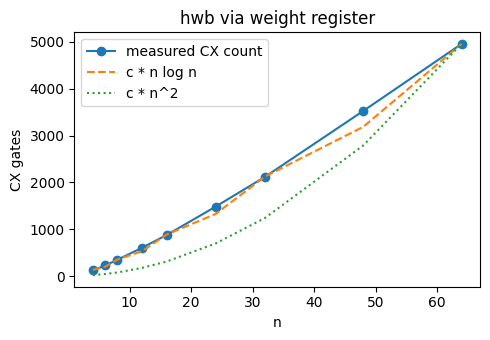

In [8]:
import matplotlib.pyplot as plt
ns, cxs = [], []
print(" n   k     CX    depth   CX/(n*k)")
for n in (4, 6, 8, 12, 16, 24, 32, 48, 64):
    qc, k = hwb_circuit(n)
    t = transpile(qc, basis_gates=['cx', 'rz', 'sx', 'x'], optimization_level=1)
    cx = t.count_ops().get('cx', 0); ns.append(n); cxs.append(cx)
    print(f"{n:3d} {k:3d} {cx:7d} {t.depth():7d}   {cx/(n*k):6.2f}")
nl = np.array(ns) * np.ceil(np.log2(np.array(ns) + 1))
plt.figure(figsize=(5, 3.5)); plt.plot(ns, cxs, 'o-', label='measured CX count')
plt.plot(ns, cxs[-1] * nl / nl[-1], '--', label='c * n log n')
plt.plot(ns, cxs[-1] * np.array(ns)**2 / ns[-1]**2, ':', label='c * n^2')
plt.xlabel('n'); plt.ylabel('CX gates'); plt.legend(); plt.title('hwb via weight register'); plt.tight_layout(); plt.show()

## 5. Status and next steps
* Verified: Algorithm 2 on superpositions (exact), DNA mismatch counting (466/466 random pairs), `hwb` (all inputs n=3..7), CX count $\approx 11\text{–}12.6\cdot n\lceil\log_2(n+1)\rceil$.
* Not yet done: depth-optimal circuit (repetition-code + semiclassical IQFT), noise models, ZNE, real-hardware runs, statistics over many reads.
* Everything above is noiseless simulation. A publishable claim about *noise robustness* needs the noisy experiments.